In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

sa2 = gpd.read_file('/Users/bob/Downloads/Raw Data/SA2_2021_AUST_SHP_GDA2020')

print(f"Shape: {sa2.shape}")        
print(f"CRS: {sa2.crs}")            

Shape: (2473, 17)
CRS: EPSG:7844


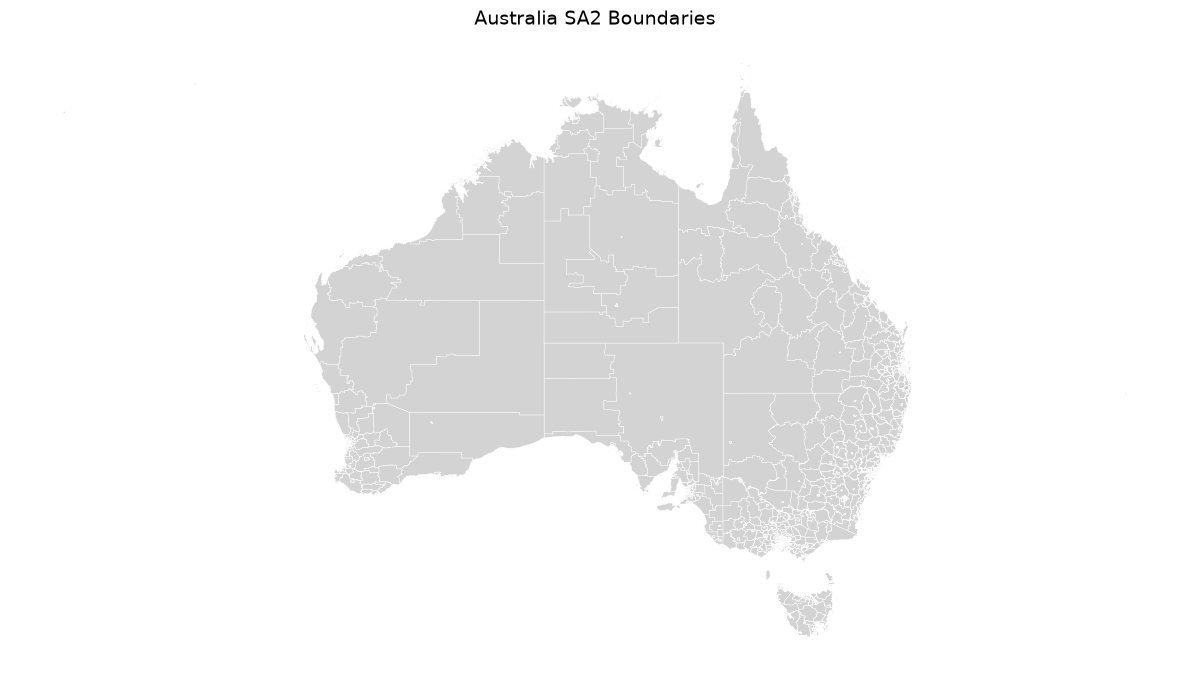

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

sa2.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.3
)

ax.set_title('Australia SA2 Boundaries', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('/Users/bob/Downloads/Raw Data/sa2_boundaries.png', dpi=150)
plt.show()

In [3]:
import geopandas as gpd
import pandas as pd

# Load SA2 boundaries (đã có)
sa2 = gpd.read_file('/Users/bob/Downloads/Raw Data/SA2_2021_AUST_SHP_GDA2020')

# Load Postal Area boundaries
poa = gpd.read_file('/Users/bob/Downloads/Raw Data/POA_2021_AUST_GDA2020_SHP')

print(sa2.shape)
sa2.head()

(2473, 17)


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [4]:
print(poa.shape)
poa.head()

(2644, 9)


,POA_CODE21,POA_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry
0,0800,0800,AUS,Australia,3.1731,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.081893,0.000264,"POLYGON ((130.83681 -12.45376, 130.83684 -12.4..."
1,0810,0810,AUS,Australia,24.4283,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.241859,0.002031,"POLYGON ((130.89986 -12.36567, 130.89875 -12.3..."
2,0812,0812,AUS,Australia,35.8899,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.278788,0.002983,"POLYGON ((130.91915 -12.40786, 130.91831 -12.4..."
3,0820,0820,AUS,Australia,39.0642,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.409134,0.003248,"POLYGON ((130.8526 -12.43994, 130.85089 -12.43..."
4,0822,0822,AUS,Australia,150775.8030,http://linked.data.gov.au/dataset/asgsed3/POA/...,90.601831,12.564238,"MULTIPOLYGON (((136.56648 -12.08392, 136.56704..."


In [5]:
# Load AAA registration data
ev = pd.read_excel('/Users/bob/Downloads/Raw data/EV_Index_Registration_Data_2021-2025.xlsx', sheet_name = "Registration Numbers")

print(f"EV data shape: {ev.shape}")
print(f"EV columns: {ev.columns.tolist()}")
ev.head()

EV data shape: (7302, 8)
EV columns: ['Postcode', 'State', 'Fuel Type', '31-Jan-2021', '31-Jan-2022', '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']


,Postcode,State,Fuel Type,31-Jan-2021,31-Jan-2022,31-Jan-2023,31-Jan-2024,31-Jan-2025
0,800,NT,BEV,3,3,12,20,38
1,800,NT,Hybrid/PHEV,131,413,401,435,613
2,800,NT,ICE,6780,7313,7088,6574,6287
3,810,NT,BEV,6,16,22,75,155
4,810,NT,Hybrid/PHEV,288,375,467,592,961


In [6]:
# Standardise postcode format in EV data
ev['Postcode'] = ev['Postcode'].astype(str).str.zfill(4)
print(ev['Postcode'].head())
print(poa['POA_CODE21'].head())

0    0800
1    0800
2    0800
3    0810
4    0810
Name: Postcode, dtype: str
0    0800
1    0810
2    0812
3    0820
4    0822
Name: POA_CODE21, dtype: str


In [7]:
# Merge EV data with POA shapefile on postcode
ev_geo = poa.merge(
    ev[ev['Fuel Type'] == 'BEV'],  # BEV only for now
    left_on='POA_CODE21',
    right_on='Postcode',
    how='left'
)
print(f"Shape after merge: {ev_geo.shape}")
print(f"Null count in 31-Jan-2025: {ev_geo['31-Jan-2025'].isna().sum()}")

Shape after merge: (2644, 17)
Null count in 31-Jan-2025: 502


In [8]:
# How many POAs matched EV data?
matched = ev_geo['31-Jan-2025'].notna().sum()
total = len(ev_geo)
print(f"Matched: {matched}/{total} ({matched/total*100:.1f}%)")

Matched: 2142/2644 (81.0%)


In [9]:
import geopandas as gpd
import pandas as pd

# ── 1. RELOAD CLEAN INPUTS ──────────────────────────────────────
sa2_projected = sa2.to_crs(epsg=3577)

ev_geo_projected = ev_geo.to_crs(epsg=3577)
ev_geo_projected['geometry'] = ev_geo_projected.geometry.centroid

In [10]:
# ── 2. PRIMARY SPATIAL JOIN (within) ───────────────────────────
ev_sa2 = gpd.sjoin(
    ev_geo_projected,
    sa2_projected[['SA2_CODE21', 'SA2_NAME21',
                   'STE_NAME21', 'geometry']],
    how='left',
    predicate='within'
)

print(f"After within join: {ev_sa2.shape}")
print(f"SA2 nulls: {ev_sa2['SA2_CODE21'].isna().sum()}")

After within join: (2644, 21)
SA2 nulls: 25


In [11]:
# ── 3. FILL NULL POSTCODES (data quality) ────────────────
ev_sa2['Postcode'] = ev_sa2['Postcode'].fillna(
    ev_sa2['POA_CODE21']
)

print(f"Null postcodes after fill: {ev_sa2['Postcode'].isna().sum()}")
print(f"Shape: {ev_sa2.shape}")

Null postcodes after fill: 0
Shape: (2644, 21)


In [12]:
# ── 4. FIX REMAINING SA2 NULLS WITH NEAREST JOIN ───────────────
still_null = ev_sa2[ev_sa2['SA2_CODE21'].isna()].copy()
has_sa2 = ev_sa2[ev_sa2['SA2_CODE21'].notna()].copy()

print(f"Coastal/edge nulls to fix: {len(still_null)}")

# Nearest SA2 for coastal centroids
still_null_fixed = gpd.sjoin_nearest(
    still_null.drop(columns=['index_right', 
                             'SA2_CODE21', 'SA2_NAME21',
                             'STE_NAME21'], 
                   errors='ignore'),
    sa2_projected[['SA2_CODE21', 'SA2_NAME21',
                   'STE_NAME21', 'geometry']],
    how='left'
)

Coastal/edge nulls to fix: 25


In [13]:
# ── 5. COMBINE ──────────────────────────────────────────────────
year_cols = ['31-Jan-2021', '31-Jan-2022',
             '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']

keep_cols = ['Postcode', 'SA2_CODE21', 'SA2_NAME21',
             'STE_NAME21'] + year_cols

ev_clean = pd.concat([
    has_sa2[keep_cols],
    still_null_fixed[keep_cols]
], ignore_index=True)

In [14]:
# ── 6. FILL NaN BEV COUNTS WITH 0 (not drop) ───────────────────
ev_clean[year_cols] = ev_clean[year_cols].fillna(0)

print(f"\nFinal shape: {ev_clean.shape}")
print(f"Remaining SA2 nulls: {ev_clean['SA2_CODE21'].isna().sum()}")
print(f"Remaining BEV nulls: {ev_clean[year_cols].isna().sum().sum()}")


Final shape: (2644, 9)
Remaining SA2 nulls: 3
Remaining BEV nulls: 0


In [15]:
null_sa2 = ev_clean[ev_clean['SA2_CODE21'].isna()]
print(null_sa2[['Postcode'] + year_cols])

     Postcode  31-Jan-2021  31-Jan-2022  31-Jan-2023  31-Jan-2024  31-Jan-2025
2641     9494          0.0          0.0          0.0          0.0          0.0
2642     9797          0.0          0.0          0.0          0.0          0.0
2643     ZZZZ          0.0          0.0          0.0          0.0          0.0


In [16]:
ev_clean = ev_clean.dropna(subset=['SA2_CODE21'])
print(f"Final clean shape: {ev_clean.shape}") 
print(f"SA2 nulls: {ev_clean['SA2_CODE21'].isna().sum()}")

Final clean shape: (2641, 9)
SA2 nulls: 0


In [27]:
# Rebuild sa2_lookup from ev_clean
sa2_lookup = ev_clean[['Postcode', 'SA2_CODE21', 
                        'SA2_NAME21', 'STE_NAME21']].drop_duplicates()

print(f"sa2_lookup shape: {sa2_lookup.shape}")
print(f"Unique postcodes: {sa2_lookup['Postcode'].nunique()}")
print(sa2_lookup.head(5))

sa2_lookup shape: (2641, 4)
Unique postcodes: 2641
  Postcode SA2_CODE21              SA2_NAME21          STE_NAME21
0     0800  701011002             Darwin City  Northern Territory
1     0810  701021013        Brinkin - Nakara  Northern Territory
2     0812  701021014           Buffalo Creek  Northern Territory
3     0820  701011006  Ludmilla - The Narrows  Northern Territory
4     0822  702031057               Alligator  Northern Territory


In [17]:
# ── 7. MELT TO LONG PANEL ───────────────────────────────────────
ev_long = ev_clean.melt(
    id_vars=['Postcode', 'SA2_CODE21',
             'SA2_NAME21', 'STE_NAME21'],
    value_vars=year_cols,
    var_name='date',
    value_name='bev_count'
)

ev_long['year'] = pd.to_datetime(
    ev_long['date'], format='%d-%b-%Y'
).dt.year

ev_long = ev_long.drop(columns=['date'])
ev_long = ev_long.sort_values(
    ['Postcode', 'year']
).reset_index(drop=True)

print(f"Long panel shape: {ev_long.shape}")
print(f"Years: {sorted(ev_long['year'].unique())}")
print(f"Postcodes: {ev_long['Postcode'].nunique()}")
print(ev_long.head(10))

Long panel shape: (13205, 6)
Years: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Postcodes: 2641
  Postcode SA2_CODE21        SA2_NAME21          STE_NAME21  bev_count  year
0     0800  701011002       Darwin City  Northern Territory        3.0  2021
1     0800  701011002       Darwin City  Northern Territory        3.0  2022
2     0800  701011002       Darwin City  Northern Territory       12.0  2023
3     0800  701011002       Darwin City  Northern Territory       20.0  2024
4     0800  701011002       Darwin City  Northern Territory       38.0  2025
5     0810  701021013  Brinkin - Nakara  Northern Territory        6.0  2021
6     0810  701021013  Brinkin - Nakara  Northern Territory       16.0  2022
7     0810  701021013  Brinkin - Nakara  Northern Territory       22.0  2023
8     0810  701021013  Brinkin - Nakara  Northern Territory       75.0  2024
9     0810  701021013  Brinkin - Nakara  Northern Territory      155.0  2025


In [18]:
print(ev_clean.shape)          # Should be (2641, 9)
print(ev_clean.columns.tolist())

(2641, 9)
['Postcode', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21', '31-Jan-2021', '31-Jan-2022', '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']


In [35]:
import geopandas as gpd
import pandas as pd

# ── CONSTANTS ───────────────────────────────────────────────────
EXCEL_PATH = '/Users/bob/Downloads/Raw data/EV_Index_Registration_Data_2021-2025.xlsx'
SHEET_NAME = "Registration Numbers"
FAKE_POSTCODES = ['9494', '9797', 'ZZZZ']
YEAR_COLS = ['31-Jan-2021', '31-Jan-2022', 
             '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']

In [36]:
# ── STEP 1: LOAD ALL FUEL TYPES ─────────────────────────────────
ev_all = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)

# Standardise postcode to 4-digit string
ev_all['Postcode'] = ev_all['Postcode'].astype(str).str.zfill(4)

# Remove fake/summary rows
ev_all = ev_all[~ev_all['Postcode'].isin(FAKE_POSTCODES)]

print(f"Raw data shape: {ev_all.shape}")
print(f"Fuel types: {ev_all['Fuel Type'].value_counts().to_dict()}")

Raw data shape: (7302, 8)
Fuel types: {'ICE': 2635, 'Hybrid/PHEV': 2525, 'BEV': 2142}


In [38]:
# ── STEP 2: MELT ALL FUEL TYPES TO LONG FORMAT ──────────────────
ev_all_long = ev_all.melt(
    id_vars=['Postcode', 'State', 'Fuel Type'],
    value_vars=YEAR_COLS,
    var_name='date',
    value_name='count'
)

ev_all_long['year'] = pd.to_datetime(
    ev_all_long['date'], format='%d-%b-%Y'
).dt.year

ev_all_long = ev_all_long.drop(columns=['date'])
ev_all_long['count'] = ev_all_long['count'].fillna(0)

print(f"\nLong format shape: {ev_all_long.shape}")
print(f"Years: {sorted(ev_all_long['year'].unique())}")


Long format shape: (36510, 5)
Years: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [45]:
# ── STEP 3: CALCULATE TOTAL FLEET AND BEV PER POSTCODE/YEAR ─────
# Total fleet = sum of all fuel types
total_fleet = ev_all_long.groupby(
    ['Postcode', 'year']
)['count'].sum().reset_index()
total_fleet.columns = ['Postcode', 'year', 'total_fleet']

# BEV only
bev_only = ev_all_long[
    ev_all_long['Fuel Type'] == 'BEV'
][['Postcode', 'year', 'count']].rename(
    columns={'count': 'bev_count'}
)

# Left join from total_fleet to keep ALL postcodes
# including zero-BEV ones
adoption = total_fleet.merge(
    bev_only, on=['Postcode', 'year'], how='left'
)
adoption['bev_count'] = adoption['bev_count'].fillna(0)
adoption['adoption_rate'] = (
    adoption['bev_count'] / adoption['total_fleet']
).fillna(0)

print(f"\nAdoption panel shape: {adoption.shape}")
print(f"Postcodes: {adoption['Postcode'].nunique()}")
print(adoption.head(6))


Adoption panel shape: (13175, 5)
Postcodes: 2635
  Postcode  year  total_fleet  bev_count  adoption_rate
0     0800  2021         6914        3.0       0.000434
1     0800  2022         7729        3.0       0.000388
2     0800  2023         7501       12.0       0.001600
3     0800  2024         7029       20.0       0.002845
4     0800  2025         6938       38.0       0.005477
5     0810  2021        22150        6.0       0.000271


In [46]:
# ── STEP 4: BUILD SA2 LOOKUP FROM SPATIAL JOIN ──────────────────
# Use ev_clean which already has the spatial join results
# Drop the 6 known bad postcodes
BAD_POSTCODES = ['6798', '6799', '6427', '2898', '6182', '2899']

sa2_lookup = ev_clean[
    ~ev_clean['Postcode'].isin(BAD_POSTCODES)
][['Postcode', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21']]\
    .drop_duplicates(subset=['Postcode'])

print(f"\nSA2 lookup shape: {sa2_lookup.shape}")
print(f"Unique postcodes: {sa2_lookup['Postcode'].nunique()}")


SA2 lookup shape: (2635, 4)
Unique postcodes: 2635


In [49]:
# ── STEP 5: MERGE SA2 GEOGRAPHY ONTO ADOPTION PANEL ─────────────
ev_master = adoption.merge(
    sa2_lookup, on='Postcode', how='left'
)

# Drop rows with no SA2 match (external territories)
ev_master = ev_master.dropna(subset=['SA2_CODE21'])

print(f"\nMaster panel shape: {ev_master.shape}")
print(f"Postcodes: {ev_master['Postcode'].nunique()}")
print(f"SA2 nulls: {ev_master['SA2_CODE21'].isna().sum()}")
print(f"BEV nulls: {ev_master['bev_count'].isna().sum()}")
print(f"\nSample output:")
print(ev_master.head(10).to_string())


Master panel shape: (13175, 8)
Postcodes: 2635
SA2 nulls: 0
BEV nulls: 0

Sample output:
  Postcode  year  total_fleet  bev_count  adoption_rate SA2_CODE21        SA2_NAME21          STE_NAME21
0     0800  2021         6914        3.0       0.000434  701011002       Darwin City  Northern Territory
1     0800  2022         7729        3.0       0.000388  701011002       Darwin City  Northern Territory
2     0800  2023         7501       12.0       0.001600  701011002       Darwin City  Northern Territory
3     0800  2024         7029       20.0       0.002845  701011002       Darwin City  Northern Territory
4     0800  2025         6938       38.0       0.005477  701011002       Darwin City  Northern Territory
5     0810  2021        22150        6.0       0.000271  701021013  Brinkin - Nakara  Northern Territory
6     0810  2022        22478       16.0       0.000712  701021013  Brinkin - Nakara  Northern Territory
7     0810  2023        22390       22.0       0.000983  701021013  Br

In [48]:
# ── STEP 6: SAVE ────────────────────────────────────────────────
ev_master = ev_master[~ev_master['Postcode'].isin(missing)]
ev_clean = ev_clean[~ev_clean['Postcode'].isin(missing)]

# Save progress
ev_master.to_csv('/Users/bob/Downloads/Clean data/ev_master_base.csv', index=False)
ev_clean.to_csv('/Users/bob/Downloads/Clean data/ev_clean_sa2.csv', index=False)

print(f"ev_master: {ev_master.shape}")  # Expect (13,175, 8)
print(f"ev_clean: {ev_clean.shape}")    # Expect (2,635, 9)
print("Saved.")

ev_master: (13175, 8)
ev_clean: (2635, 9)
Saved.
